In [1]:
n_layers = 24
d_model = 256
n_heads = 8
seq_len = 128

In [4]:
import torch

In [2]:
from transformers import AutoModel, AutoTokenizer

model_name = "bert-large-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

/home/ek/.venvs/playground/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:00<00:00, 5189.98it/s]
[transformers] BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECT

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 1024, padding_idx=0)
    (position_embeddings): Embedding(512, 1024)
    (token_type_embeddings): Embedding(2, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-23): 24 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout

In [73]:
text = """
The first permanent cities on Mars would not resemble the futuristic landscapes often imagined in science fiction, but rather carefully engineered environments designed around survival, efficiency, and adaptation. A Martian settlement would likely begin as a small collection of interconnected habitats protected from radiation and extreme temperature changes, with many structures built underground or covered by layers of Martian soil to provide shielding. Every resource would have to be managed carefully because importing materials from Earth would be expensive and slow, meaning settlers would need to extract water from underground ice deposits, produce oxygen from local resources, recycle nearly all waste, and grow food in controlled environments. Over time, these early outposts could develop into larger communities with laboratories, manufacturing facilities, schools, and eventually cultural institutions. Life on Mars would still contain many familiar elements of human civilization, such as friendships, creativity, competition, and curiosity, but daily routines would be shaped by the realities of living on another planet. People would experience weaker gravity, delayed communication with Earth, limited outdoor activity, and a constant awareness that their environment could not support human life without technology. Children born on Mars might grow up with a completely different understanding of humanity's place in the universe, seeing Earth not as the entire world but as one of two homes. The development of a Martian society would raise important questions about governance, identity, and independence, because a community separated by millions of kilometres would eventually need to make decisions based on its own circumstances. Despite the challenges, a successful settlement on Mars would represent one of the greatest achievements in human history, demonstrating not only technological progress but also humanity's ability to adapt, cooperate, and extend life beyond the planet where it began.
"""
inputs = tokenizer(
    text,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = model(**inputs)

In [74]:
def analyze_attention(outputs, attention_mask=None):

    entropy = []
    effective_tokens = []
    max_attention = []

    for layer_attn in outputs.attentions:

        # (heads, query, key)
        A = layer_attn[0]

        heads = A.shape[0]

        layer_entropy = []
        layer_eff = []
        layer_max = []

        for h in range(heads):

            head_entropy = []
            head_eff = []
            head_max = []

            for q in range(A.shape[1]):

                probs = A[h, q]

                # remove padding keys
                if attention_mask is not None:
                    probs = probs[attention_mask.bool()]

                H = -(probs * torch.log(probs + 1e-12)).sum()

                eff = 1 / (probs**2).sum()

                mx = probs.max()

                head_entropy.append(H.item())
                head_eff.append(eff.item())
                head_max.append(mx.item())

            layer_entropy.append(
                sum(head_entropy)/len(head_entropy)
            )

            layer_eff.append(
                sum(head_eff)/len(head_eff)
            )

            layer_max.append(
                sum(head_max)/len(head_max)
            )

        entropy.append(layer_entropy)
        effective_tokens.append(layer_eff)
        max_attention.append(layer_max)

    return (
        torch.tensor(entropy),
        torch.tensor(effective_tokens),
        torch.tensor(max_attention)
    )

In [75]:
entropy, neff, pmax = analyze_attention(
    outputs,
    inputs["attention_mask"][0]
)

print(entropy.shape)

torch.Size([24, 16])


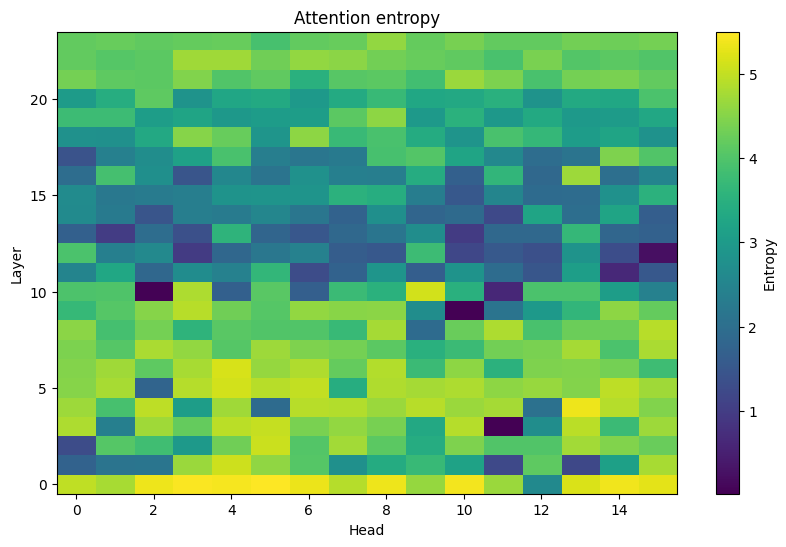

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(
    entropy,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Entropy")

plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Attention entropy")

plt.show()

In [77]:
import torch
import matplotlib.pyplot as plt


def analyze_temperature_schedule(
    outputs,
    attention_mask=None,
    logits=None
):
    """
    Computes layer-wise attention statistics.

    outputs.attentions:
        tuple(num_layers)
        (batch, heads, query, key)

    logits:
        optional tuple(num_layers)
        raw QK scores
    """

    entropy = []
    norm_entropy = []
    effective_tokens = []
    score_std = []


    for l, attn in enumerate(outputs.attentions):

        # remove batch
        A = attn[0]
        # heads, query, key

        H_layer = []
        Hnorm_layer = []
        Neff_layer = []


        for h in range(A.shape[0]):

            for q in range(A.shape[1]):

                probs = A[h,q]

                # remove padding
                if attention_mask is not None:
                    probs = probs[attention_mask.bool()]

                n = len(probs)

                H = -(probs * torch.log(probs + 1e-12)).sum()

                Hnorm = H / torch.log(
                    torch.tensor(float(n))
                )

                Neff = 1 / (probs**2).sum()


                H_layer.append(H.item())
                Hnorm_layer.append(Hnorm.item())
                Neff_layer.append(Neff.item())


        entropy.append(
            sum(H_layer)/len(H_layer)
        )

        norm_entropy.append(
            sum(Hnorm_layer)/len(Hnorm_layer)
        )

        effective_tokens.append(
            sum(Neff_layer)/len(Neff_layer)
        )


        # optional score variance
        if logits is not None:

            S = logits[l][0]

            score_std.append(
                S.std().item()
            )


    return {
        "entropy": torch.tensor(entropy),
        "norm_entropy": torch.tensor(norm_entropy),
        "effective_tokens": torch.tensor(effective_tokens),
        "score_std": torch.tensor(score_std)
            if logits is not None else None
    }

In [78]:
def plot_schedule(stats):

    layers = range(len(stats["entropy"]))

    plt.figure(figsize=(10,6))

    plt.plot(
        layers,
        stats["norm_entropy"],
        marker="o",
        label="Normalized entropy"
    )

    plt.plot(
        layers,
        stats["effective_tokens"],
        marker="o",
        label="Effective tokens"
    )

    plt.xlabel("Layer")
    plt.ylabel("Value")
    plt.title("Attention concentration vs depth")

    plt.legend()
    plt.grid()

    plt.show()

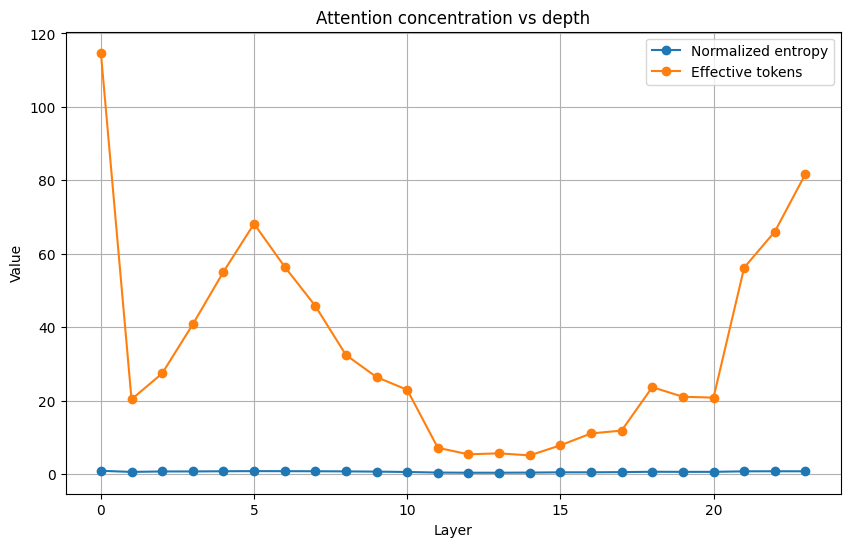

In [79]:
stats = analyze_temperature_schedule(
    outputs,
    attention_mask=inputs["attention_mask"][0]
)

plot_schedule(stats)

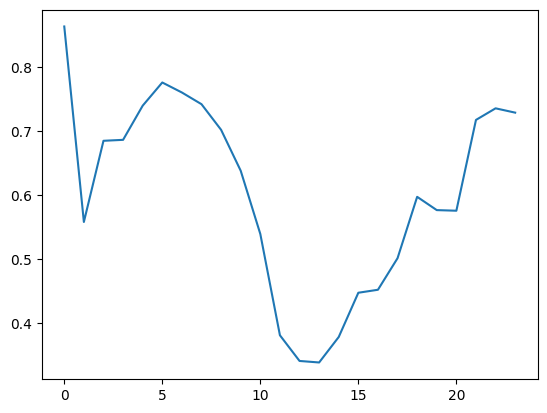

In [80]:
plt.plot(stats["norm_entropy"])

In [81]:
def lambda_from_scores(scores):
    """
    scores:
        (query_len, key_len)

    returns:
        Lambda_n
    """

    lambdas = []

    for q in range(scores.shape[0]):

        s = scores[q]

        # energy gaps
        delta = s.max() - s

        delta = delta.detach().cpu().numpy()

        # remove zero gap
        delta = delta[delta > 1e-10]

        if len(delta) == 0:
            continue

        delta = np.sort(delta)

        k = np.arange(
            1,
            len(delta)+1
        )

        values = np.log(k) / delta

        lambdas.append(
            np.max(values)
        )

    return np.mean(lambdas)

In [82]:
def lambda_from_attention(A, eps=0.1):

    log_a=torch.log(A+1e-12)

    vals=[]

    for q in range(log_a.shape[0]):

        delta=log_a[q].max()-log_a[q]

        delta=delta.cpu().numpy()

        delta=np.sort(delta[delta>eps])

        if len(delta)==0:
            continue

        k=np.arange(1,len(delta)+1)

        vals.append(
            np.max(np.log(k)/delta)
        )

    return np.mean(vals)

In [83]:
def compute_lambda_matrix(outputs):

    Lambda=[]

    for layer in outputs.attentions:

        A = layer[0]   # heads,q,k

        layer_vals=[]

        for h in range(A.shape[0]):

            lam = lambda_from_attention(
                A[h]
            )

            layer_vals.append(lam)

        Lambda.append(layer_vals)

    return torch.tensor(Lambda)

In [84]:
import numpy as np

In [85]:
Lambda = compute_lambda_matrix(outputs)

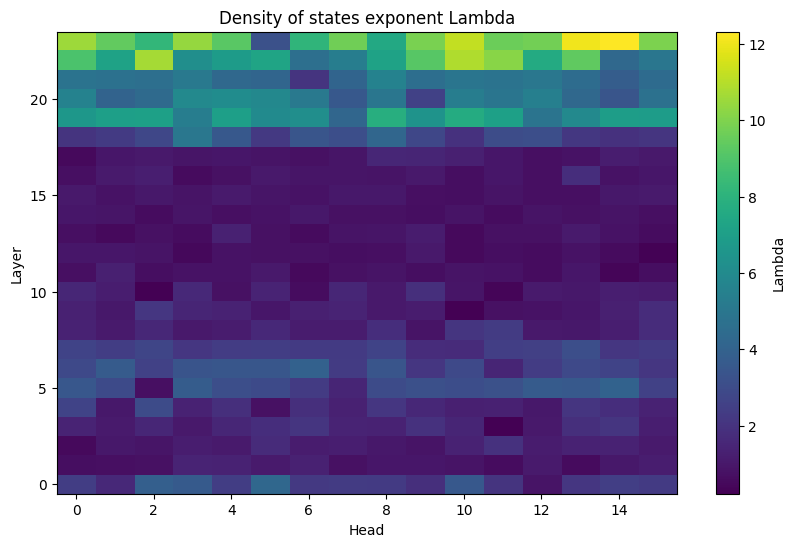

In [86]:
plt.figure(figsize=(10,6))

plt.imshow(
    Lambda.numpy(),
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Lambda")

plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Density of states exponent Lambda")

plt.show()

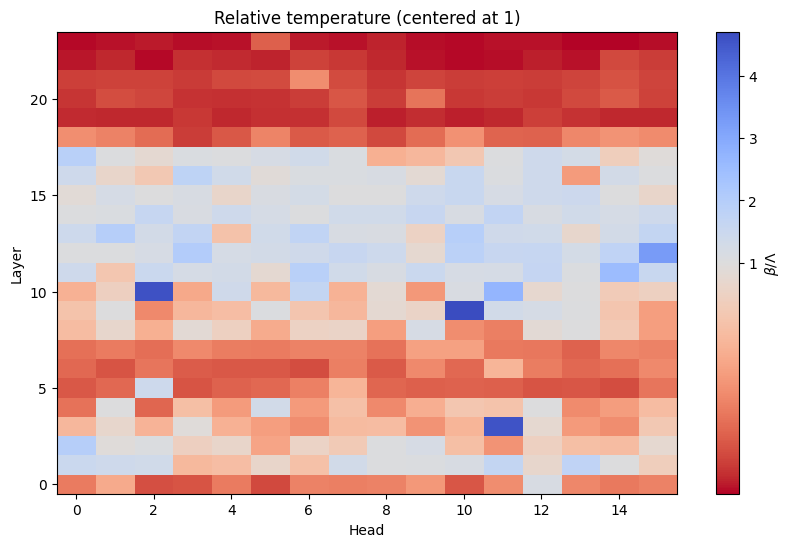

In [87]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

ratio = 1 / Lambda

norm = TwoSlopeNorm(
    vmin=ratio.min().item(),
    vcenter=1.0,
    vmax=ratio.max().item()
)

plt.figure(figsize=(10,6))

plt.imshow(
    ratio.numpy(),
    aspect="auto",
    origin="lower",
    norm=norm,
    cmap="coolwarm_r"
)

plt.colorbar(label=r"$\beta/\Lambda$")

plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Relative temperature (centered at 1)")

plt.show()